#### **Análisis y Procesamiento de Señales**
# **Trabajo Práctico Nº1 "Sintesis y operaciones de señales"**
#### Federico Dunel



## **introduccion**
En el siguiente trabajo se comenzó a programar en python un generador de funciones armonicas senoidales y de señales cuadradas. Luego se probaron distintas operaciones sobre las funciones:
1. Se amplificó la potencia y se aplicó un desfasaje
2. Se moduló la señal con otra de distinta frecuencia
3. Se aplicó un efecto de saturación en la amplitud
4. Se generó una señal cuadrada y un pulso


#### Generación de las señales en python

En se definieron dos funciones para realizar señales, una produce ondas senoidales a partir de parametros de amplitud (amp), frecuencia (ff), fase (ph), número de muestras (nn) y frecuencia de muestreo (fs). El intervalo de tiempo entre muestras esta dado por la division de n muestras sobre la frecuencia de muestreo, en todas las funciones se utilizaron N = 1000 muestras con una frecuencia de muestreo que fue variando según la frecuencia de la señal generada. El tiempo de análisis se define como nn/fs. Para poder apreciar la forma de las funciones se limitaron los graficos a algunos periodos. La otra funcion que se definio produce ondas cuadradas utilizando los mismos parametros que la funcion senoidal sumandole uno para definir los duty cicles del pulso. Para realizar un pulso de 10ms se utilizo una funcion cuadrada con una frecuencia de 20Hz (un periodo de 0.05s) con un duty cicle de 0.2, dando una sucesion de pulsos de 10ms de los cuales se muestra solo uno.

## **1) Desarrollo de funciones senoidales**


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

pi = np.pi
N = 1000 #cantidad de muestras, podria ser la cantidad de memoria disponible
fs = 50000 #frecuencia de muestreo
nn = np.arange(0,N,1)
tt = nn/fs
amp = np.sqrt(2)

ff1 = 2000

def sen(nn, fs, amp = np.sqrt(2), ff = ff1, ph = 0, dc = 0):
    tt = nn/fs
    xx = amp*np.sin((2*np.pi)*ff*tt + ph) + dc
    return tt, xx



**1) Señal senoidal de frecuencia 2000Hz**

Esto nos devuelve una función con un periodo de 1/2000 seg. Para que posea una potencia unitaria se le dió una amplitud igual a $\sqrt{2}$V.

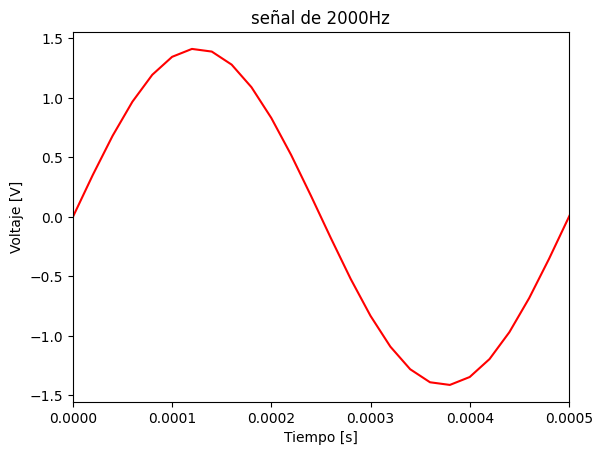

la potencia de la señal es 0.9999999999999997 Watt con un periodo de 0.0005 s


In [4]:
tt1, xx1 = sen(nn = nn, fs = fs, ff = 2000)
Pxx1 = np.mean(np.abs(xx1)**2)
Per1 = 1/ff1

plt.figure(1)
plt.plot(tt1, xx1, color = 'red')
plt.title("señal de 2000Hz")
plt.xlim([0,1/ff1])
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.show()

print("la potencia de la señal es", Pxx1,"Watt", "con un periodo de", Per1, "s")

**2) Senoidal aumentada en 3db y desfazada en $\frac{\pi}{2}$**

Para aumentar la potencia de la señal en 3db primero se calculó cuanto aumento de potencia equivale este valor.
De la formula  $P_{\mathrm{dB}} = 10 \log_{10}\left(\frac{P}{P_{\text{ref}}}\right)$  tomando una Potencia de referencia de 1 Watt sacamos que aumentar 3db de potencia en este caso equivalen a aumentarla por $10^{3/10} \approx 2$. Esto se consigue aumentando la amplitud de la señal de $\sqrt{2}$ a ${2}$ multiplicando la señal por $\sqrt{2}$

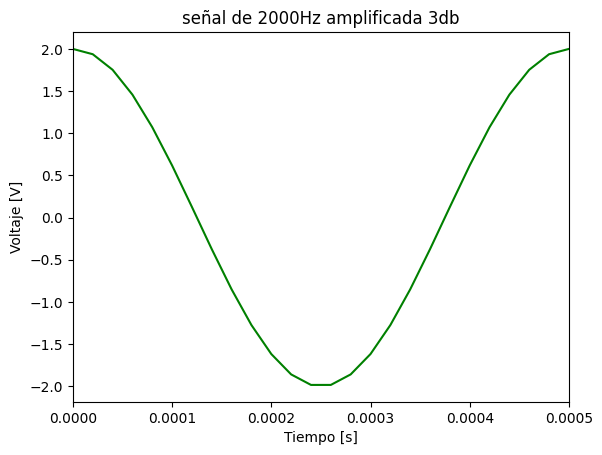

la potencia de la señal es 2.0000000000000018 Watt con un periodo de 0.0005 seg


In [8]:
tt2, xx2 = sen(nn = nn, fs = fs, amp = amp*np.sqrt(2), ff = 2000, ph = (np.pi)/2)
Pxx2 = np.mean(np.abs(xx2)**2)
Per2 = 1/ff1

plt.figure(2)
plt.plot(tt2, xx2, color = 'green')
plt.title("señal de 2000Hz amplificada 3db")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim([0,1/ff1])
plt.show()

print("la potencia de la señal es", Pxx2, "Watt", "con un periodo de", Per2, "seg")

**3) Señal de 2000Hz modulada con una señal de 1000Hz**

Se multiplicó la señal senoidal de 2000Hz por otra de 1000Hz para simular una modulación, esto da como resultado la resta de dos cosenoidales siguiendo la identidad trigonometrica:  $\sin(a)\sin(b) = \frac{1}{2}\left[\cos(a-b) - \cos(a+b)\right]$. Como resultado en este caso nos da la siguiente señal: $\sin(2\pi \cdot 1000\,t)\,\sin(2\pi \cdot 2000\,t)
= \frac{1}{2}\left[\cos(2\pi \cdot 1000\,t) - \cos(2\pi \cdot 3000\,t)\right]$. El resultado es una señal una componente de periodo 1/1000 seg y otra con 1/3000 seg, lo que nos da una señal periodica cada 1/1000 o 0,001 seg, se graficaron 2 periodos.

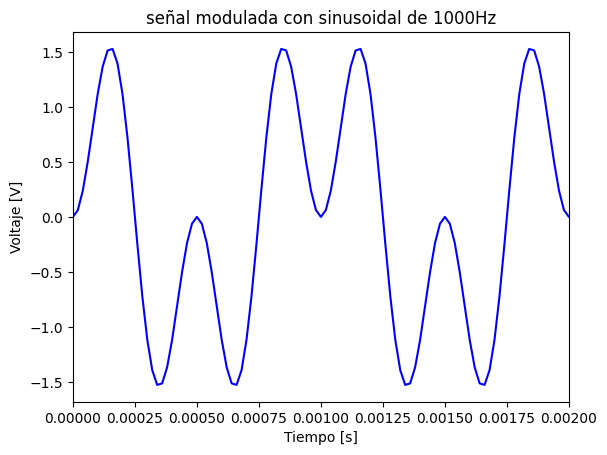

la potencia de la señal es 0.9999999999999996 con un periodo de 0.001


In [9]:
tt3, xx3 = sen(nn = nn, fs = fs, ff = 1000)
XX3 = xx1 * xx3
PXX3 = np.mean(np.abs(XX3)**2)
Per3 = 1/1000

plt.figure(3)
plt.plot(tt3, XX3, color = 'blue')
plt.title("señal modulada con sinusoidal de 1000Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim([0, (1/1000)*2])
plt.show()

print("la potencia de la señal es", PXX3, "Watt", "con un periodo de", Per3,"seg")


**4) Señal con amplitud limitada**

Se generó una nueva señal aplicandole la función de numpy np.clip a la primera senoidal, poniendo como limites superiores e inferiores el 75% de la amplitud total





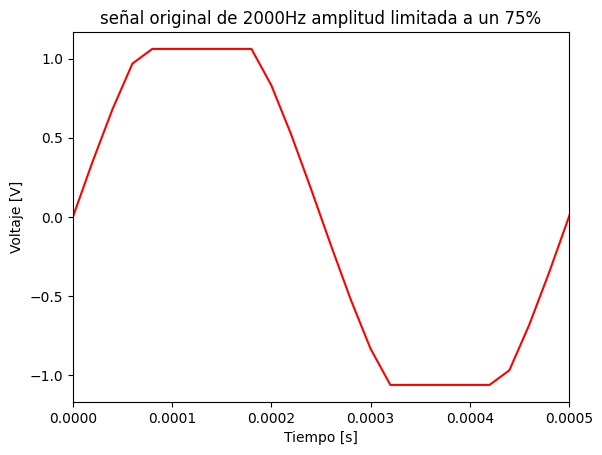

la potencia de la señal es 0.7414805778018263 Watt con un periodo de 0.0005 seg


In [10]:
xx4 = np.clip(xx1, a_min = -amp*0.75, a_max= amp*0.75)
Pxx4 = np.mean(np.abs(xx4)**2)
Per4 = 1/ff1

plt.figure(4)
plt.plot(tt1, xx4, color = 'red')
plt.title("señal original de 2000Hz amplitud limitada a un 75%")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim([0,1/ff1])
plt.show()

print("la potencia de la señal es", Pxx4, "Watt", "con un periodo de", Per4, "seg")


**5) Señal cuadrada de 4000Hz**

Se armo una funcion generadora de señales cuadradas utilizando la funcion de la biblioteca signal de scipy "square" con una frecuencia de 4000Hz, una amplitud de 1V y un duty cicle de 0,5.

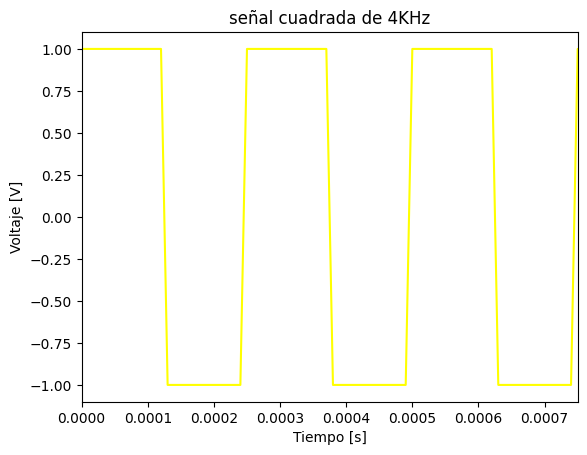

la potencia de la señal es 1.0 Watt con un periodo de 0.00025 seg


In [12]:
def funpulso (ff, nn, fs, amp = 1, dc = 0, ph = 0, duty = 0.5):
    tt = nn/fs
    xx = dc + amp * signal.square(2 * np.pi * ff * tt + ph, duty=duty)
    
    return tt, xx

tt5 , xx5 =funpulso(ff = 4000, nn = nn, fs = 100000, duty = 0.5)
Pxx5 = np.mean(np.abs(xx5)**2)
Per5 = 1/4000

plt.figure(5)
plt.plot(tt5, xx5, color = 'yellow')
plt.title("señal cuadrada de 4KHz")
plt.xlim([0,3/4000])
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.show()

print("la potencia de la señal es", Pxx5, "Watt", "con un periodo de", Per5, "seg")


**6) Pulso rectangular de 10ms**

Se generó un pulso rectangular de 1ms utilizando la función generadora de señales cuadradas, definiendola en 0.02 segundos y armandola con una frecuencia 50Hz con un dutycicle de 0,5 y limitando su valor minimo a 0.

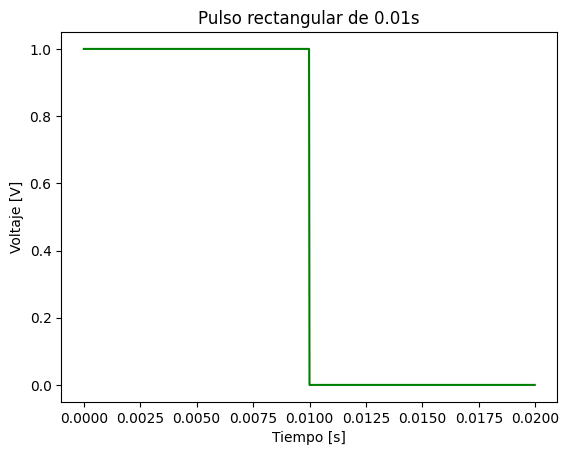

la potencia de la señal es 0.5 Watt con un periodo de 0.02 seg


In [15]:
tt6, xx6 =funpulso(ff = 50, nn = nn, fs = 50000, amp = 1.0, duty = 0.5)
XX6 = np.clip(xx6, a_min = 0, a_max = None)
Pxx6 = np.mean(np.abs(XX6)**2)
Per6 = 1/50

plt.figure(6)
plt.plot(tt6, XX6, color = 'green')
plt.title("Pulso rectangular de 0.01s")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.show()

print("la potencia de la señal es", Pxx6,"Watt", "con un periodo de", Per6,"seg")


## **Concluciones**

En este trabajo se pudo representar gráficamente distintas funciones senoidales y cuadradas programando en python. Se verificó como realizar operaciones en las señales digitales como aumentar la potencia, generar un desfasaje, limitar la amplitud a valores especificos y modular una señal con otra. También se armaron funciones que permiten representar pulsos y señales cuadradas, que luego se podran aprovechar para realizar otras experiencias. Se verificó en todo momento como afectan a la potencia distintos cambios en las señales, viendo que en las senoidales puras depende unicamente de su amplitud. En el caso de la señal modulada no hubo cambios en su potencia al ser ambas señales utilizadas de potencia normalizada.


## Analisis del aprendizaje
Utilice muchos codigos del trabajo del año pasado, sin embargo volvi a armar los graficos a mano y no necesité de la inteligencia artificial para producirlos. 